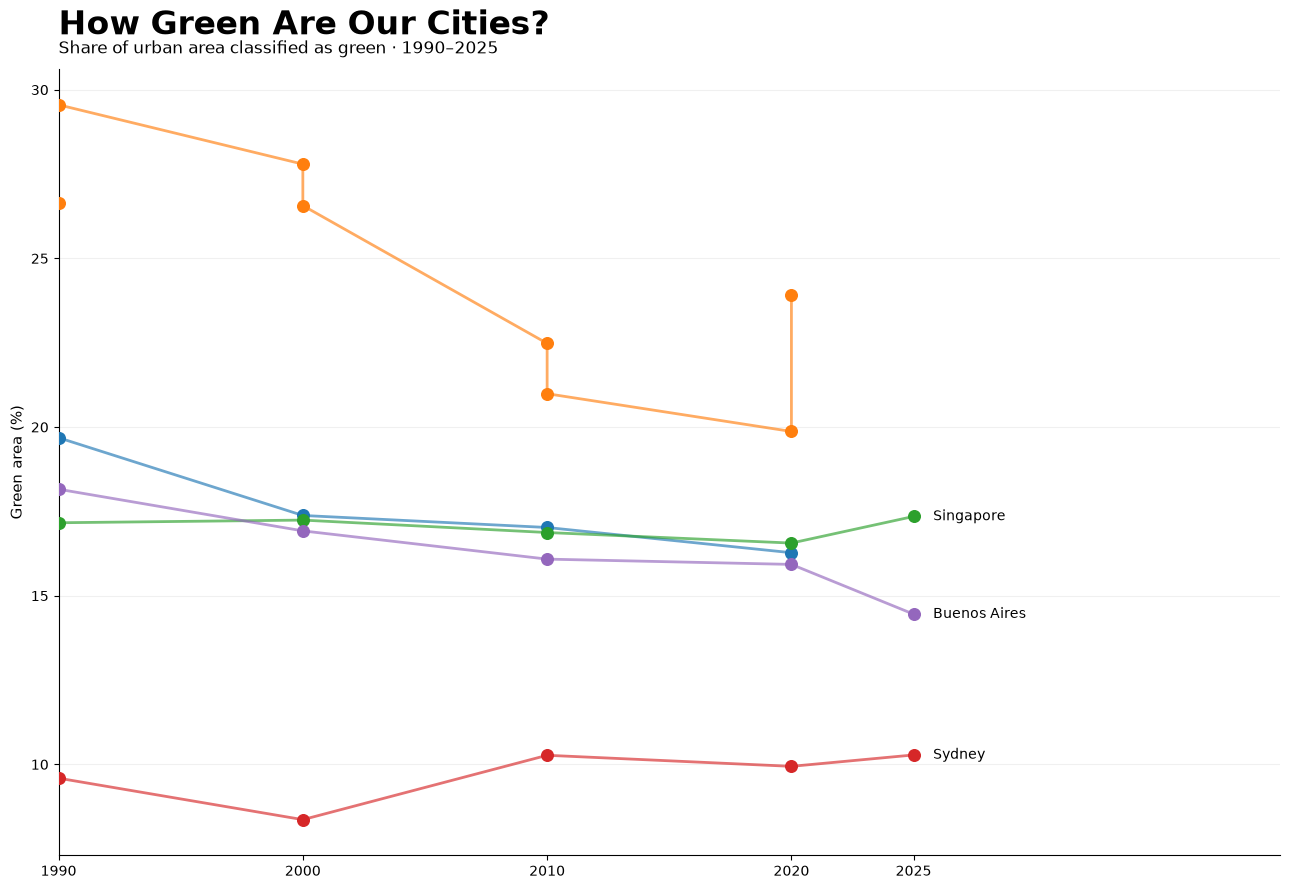

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
url = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/"
    "data/2026/2026-09-22/urban.csv"
)

urban = pd.read_csv(url)

# -----------------------------
# Select cities
# -----------------------------
cities = [
    "Toronto",
    "Vancouver",
    "New York City",
    "London",
    "Paris",
    "Tokyo",
    "Singapore",
    "Sydney",
    "Mexico City",
    "Buenos Aires"
]

plot_df = urban[
    urban["cityName"].isin(cities)
].copy()

# -----------------------------
# Create chart
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 9))

for city in cities:

    city_data = (
        plot_df[plot_df["cityName"] == city]
        .sort_values("year")
    )

    if len(city_data) == 0:
        continue

    x = city_data["year"]
    y = city_data[
        "averageShareOfGreenAreaInCityUrbanAreaPct"
    ]

    # Connecting line
    ax.plot(
        x,
        y,
        linewidth=2,
        alpha=0.65
    )

    # Circles
    ax.scatter(
        x,
        y,
        s=70,
        zorder=3
    )

    # Label at the latest year
    last = city_data.iloc[-1]

    ax.text(
        last["year"] + 0.8,
        last["averageShareOfGreenAreaInCityUrbanAreaPct"],
        city,
        va="center",
        fontsize=10
    )

# -----------------------------
# Formatting
# -----------------------------
ax.set_title(
    "How Green Are Our Cities?",
    fontsize=24,
    fontweight="bold",
    loc="left",
    pad=25
)

ax.text(
    0,
    1.02,
    "Share of urban area classified as green · 1990–2025",
    transform=ax.transAxes,
    fontsize=12
)

ax.set_xlabel("")
ax.set_ylabel("Green area (%)", fontsize=11)

ax.set_xticks([1990, 2000, 2010, 2020, 2025])

ax.grid(
    axis="y",
    alpha=0.18
)

# Give labels room on the right
ax.set_xlim(1990, 2040)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

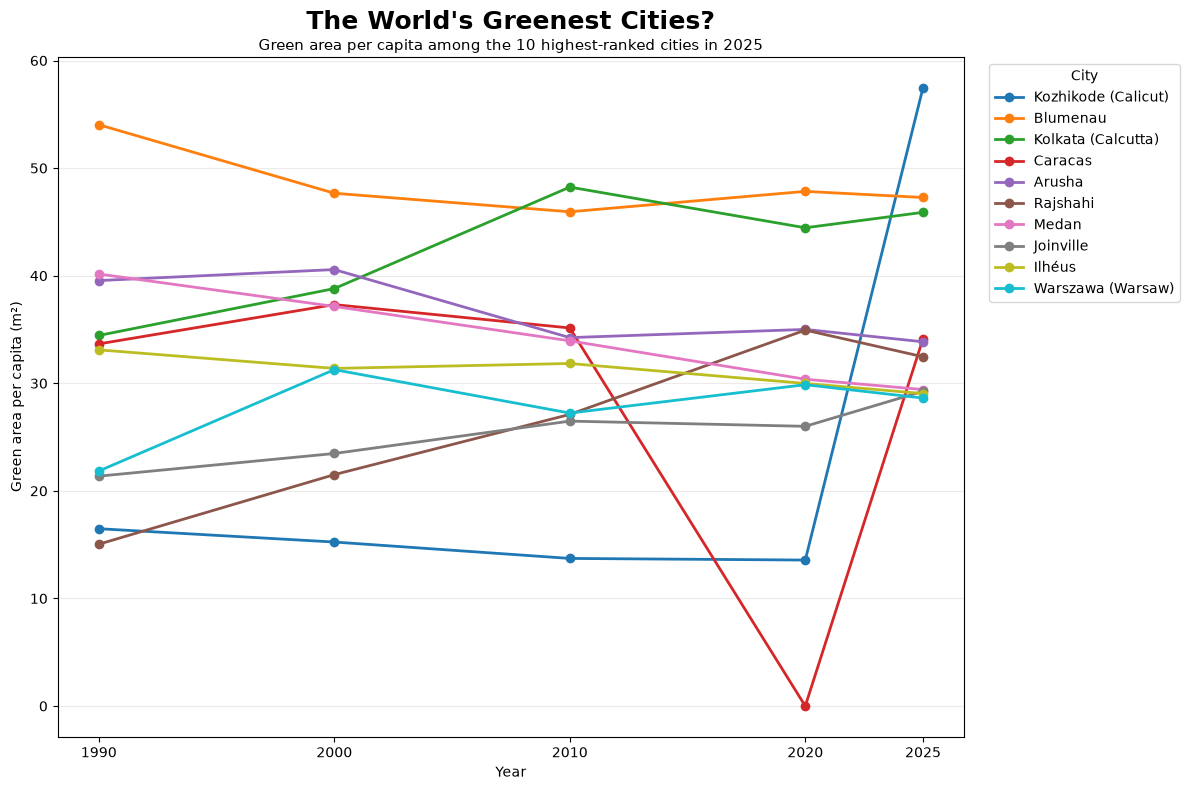

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
url = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/"
    "data/2026/2026-09-22/urban.csv"
)

urban = pd.read_csv(url)

# Find the top 10 cities by green area per capita in 2025
top_cities = (
    urban[urban["year"] == 2025]
    .nlargest(10, "greenAreaPerCapitaM2")["cityName"]
    .tolist()
)

# Keep only those cities
plot_df = urban[urban["cityName"].isin(top_cities)].copy()

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

for city in top_cities:
    city_data = plot_df[plot_df["cityName"] == city].sort_values("year")

    ax.plot(
        city_data["year"],
        city_data["greenAreaPerCapitaM2"],
        marker="o",
        linewidth=2,
        label=city
    )

ax.set_title(
    "The World's Greenest Cities?",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.text(
    0.5, 1.01,
    "Green area per capita among the 10 highest-ranked cities in 2025",
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

ax.set_xlabel("Year")
ax.set_ylabel("Green area per capita (m²)")

ax.set_xticks([1990, 2000, 2010, 2020, 2025])

ax.grid(axis="y", alpha=0.25)

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()